In [1]:
#N1: imports + dataset path

import os
N_THREADS = 16                                   # 64 cores / 4 notebooks
os.environ["OMP_NUM_THREADS"] = str(N_THREADS)   # must be set BEFORE importing torch/numpy
os.environ["MKL_NUM_THREADS"] = str(N_THREADS)
import torch
torch.set_num_threads(N_THREADS)                 # PyTorch uses only these cores
print("threads:", torch.get_num_threads())

# os.sched_setaffinity(0, range(0, 16))    # file 1 (compound)
# os.sched_setaffinity(0, range(16, 32))    # file 2 (independent)
os.sched_setaffinity(0, range(32, 48))    # file 3 (b=[1,0,0,0])
# os.sched_setaffinity(0, range(48, 64))    # file 4 (wide)

import os, glob
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from PIL import Image
import time
import matplotlib.pyplot as plt

BASE = '/home/worker/Downloads/talha/week6/fruit notebooks/fruits-360/'   

TRAIN_DIR = os.path.join(BASE, 'Training')
TEST_DIR  = os.path.join(BASE, 'Test')
all_classes = sorted(os.listdir(TRAIN_DIR))

print(f"{len(all_classes)} classes")


threads: 16
268 classes


In [2]:
#N2: 6 problems x 5 classes 
# Each group holds classes that look alike, like the CIFAR-100 superclasses did.

SCRIPT_NAMES = ["P1_apples", "P2_citrus", "P3_berries", "P4_tropical", "P5_vegetables", "P6_stone_pear"]

GROUP_FOLDERS = [
    ["Apple Braeburn 1", "Apple Golden 1", "Apple Granny Smith 1", "Apple Pink Lady 1", "Apple Red Delicious 1"],  # P1
    ["Clementine 1", "Grapefruit Pink 1", "Lemon 1", "Limes 1", "Orange 1"],                                    # P2
    ["Blueberry 1", "Cherry 1", "Raspberry 1", "Redcurrant 1", "Strawberry 1"],                                 # P3
    ["Banana 1", "Kiwi 1", "Mango 1", "Papaya 1", "Pineapple 1"],                                               # P4
    ["Eggplant 1", "Onion White 1", "Pepper Red 1", "Potato Red 1", "Tomato 1"],                                # P5
    ["Apricot 1", "Nectarine 1", "Peach 1", "Pear 1", "Plum 1"],                                                # P6
]

missing = [f for grp in GROUP_FOLDERS for f in grp if f not in all_classes]
assert not missing, f"these folders don't exist: {missing}"
flat = [f for grp in GROUP_FOLDERS for f in grp]
assert len(set(flat)) == len(flat), "the same class is used in two groups"

for name, grp in zip(SCRIPT_NAMES, GROUP_FOLDERS):
    print(f"{name:14s} {grp}")
print("\n6 problems, 5 classes each, 30 classes used")


P1_apples      ['Apple Braeburn 1', 'Apple Golden 1', 'Apple Granny Smith 1', 'Apple Pink Lady 1', 'Apple Red Delicious 1']
P2_citrus      ['Clementine 1', 'Grapefruit Pink 1', 'Lemon 1', 'Limes 1', 'Orange 1']
P3_berries     ['Blueberry 1', 'Cherry 1', 'Raspberry 1', 'Redcurrant 1', 'Strawberry 1']
P4_tropical    ['Banana 1', 'Kiwi 1', 'Mango 1', 'Papaya 1', 'Pineapple 1']
P5_vegetables  ['Eggplant 1', 'Onion White 1', 'Pepper Red 1', 'Potato Red 1', 'Tomato 1']
P6_stone_pear  ['Apricot 1', 'Nectarine 1', 'Peach 1', 'Pear 1', 'Plum 1']

6 problems, 5 classes each, 30 classes used


P1_apples      train  2410  test  806  train per class [492, 480, 492, 456, 490]
P2_citrus      train  2441  test  822  train per class [490, 490, 492, 490, 479]
P3_berries     train  2428  test  812  train per class [462, 492, 490, 492, 492]
P4_tropical    train  2428  test  818  train per class [490, 466, 490, 492, 490]
P5_vegetables  train  2760  test  920  train per class [468, 438, 666, 450, 738]
P6_stone_pear  train  2415  test  807  train per class [492, 492, 492, 492, 447]
loaded in 2s


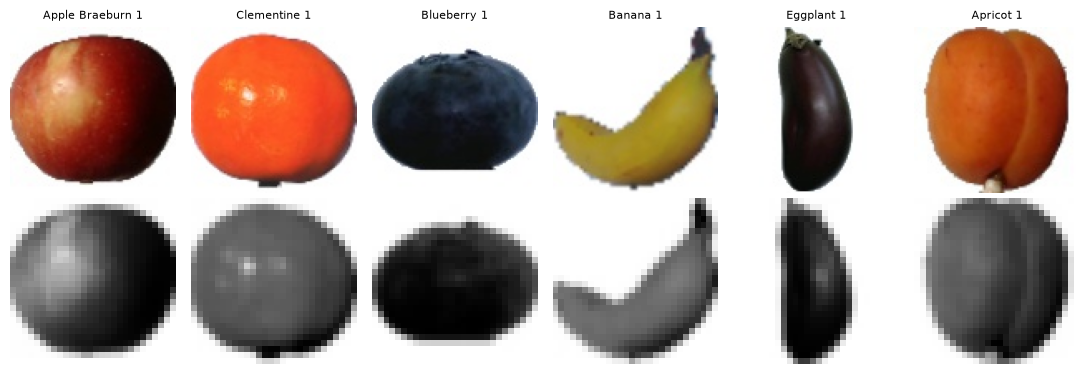

In [3]:
#N3: load images and convert to 28x28 grayscale 
# Fruits-360 images are 100x100 colour photos on a white background, already upright.

def load_class(split_dir, folder):
    paths = sorted(glob.glob(os.path.join(split_dir, folder, '*')))
    arr = np.empty((len(paths), 784), dtype=np.uint8)
    for i, p in enumerate(paths):
        img = Image.open(p).convert('L').resize((28, 28), Image.BILINEAR)   # grayscale, 100x100 -> 28x28
        arr[i] = np.asarray(img, dtype=np.uint8).reshape(-1)
    return arr

t0 = time.time()
group_data = []      # per group: (x_train, y_train, x_test, y_test), labels 0-4 = position in the group list
for m, folders in enumerate(GROUP_FOLDERS):
    xs_tr, ys_tr, xs_te, ys_te = [], [], [], []
    for label, folder in enumerate(folders):
        a_tr = load_class(TRAIN_DIR, folder)
        a_te = load_class(TEST_DIR, folder)
        xs_tr.append(a_tr); ys_tr.append(np.full(len(a_tr), label, dtype=np.int64))
        xs_te.append(a_te); ys_te.append(np.full(len(a_te), label, dtype=np.int64))
    group_data.append((np.concatenate(xs_tr), np.concatenate(ys_tr),
                       np.concatenate(xs_te), np.concatenate(ys_te)))
    per_class = [len(x) for x in xs_tr]
    print(f"{SCRIPT_NAMES[m]:14s} train {len(group_data[m][0]):5d}  test {len(group_data[m][2]):4d}  "
          f"train per class {per_class}")
print(f"loaded in {time.time()-t0:.0f}s")

# visual check: one image per group, top = original colour, bottom = 28x28 grayscale
fig, axes = plt.subplots(2, 6, figsize=(11, 3.8))
for m, folders in enumerate(GROUP_FOLDERS):
    p = sorted(glob.glob(os.path.join(TRAIN_DIR, folders[0], '*')))[0]
    axes[0, m].imshow(Image.open(p).convert('RGB')); axes[0, m].set_title(folders[0], fontsize=8)
    axes[1, m].imshow(group_data[m][0][0].reshape(28, 28), cmap='gray')
    axes[0, m].axis('off'); axes[1, m].axis('off')
plt.tight_layout(); plt.show()


In [4]:
#N4: building 6 datasets (standardized with each group's own training mean and std)

train_datasets = []
test_datasets  = []

for m in range(6):
    x_tr, y_tr, x_te, y_te = group_data[m]
    x_tr = torch.tensor(x_tr, dtype=torch.float32)
    x_te = torch.tensor(x_te, dtype=torch.float32)
    y_tr = torch.tensor(y_tr, dtype=torch.long)
    y_te = torch.tensor(y_te, dtype=torch.long)

    mean = x_tr.mean()
    std  = x_tr.std()
    x_tr = (x_tr - mean) / std
    x_te = (x_te - mean) / std

    train_datasets.append(TensorDataset(x_tr, y_tr))
    test_datasets.append(TensorDataset(x_te, y_te))

    print(f"{SCRIPT_NAMES[m]:14s} train {len(x_tr):5d}  test {len(x_te):4d}  "
          f"mean {x_tr.mean():.2f}  std {x_tr.std():.2f}")


P1_apples      train  2410  test  806  mean -0.00  std 1.00
P2_citrus      train  2441  test  822  mean -0.00  std 1.00
P3_berries     train  2428  test  812  mean 0.00  std 1.00
P4_tropical    train  2428  test  818  mean 0.00  std 1.00
P5_vegetables  train  2760  test  920  mean -0.00  std 1.00
P6_stone_pear  train  2415  test  807  mean -0.00  std 1.00


In [5]:
#N5: DataLoaders + settings

BATCH_SIZE = 32
train_loaders = [DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True) for ds in train_datasets]
test_loaders  = [DataLoader(ds, batch_size=256, shuffle=False)       for ds in test_datasets]

def infinite(loader):
    while True:
        for batch in loader:
            yield batch

DEVICE          = 'cpu' if torch.cuda.is_available() else 'cpu'
INPUT_SIZE      = 784           # 28*28*1 grayscale
HIDDEN_SIZE     = 128
NUM_G_SETS      = 4
NUM_PROBLEMS    = 6
CLASSES_PER     = 5
TOTAL_CLASSES   = NUM_PROBLEMS * CLASSES_PER   # 30

LEARNING_RATE   = 0.001
MOMENTUM        = 0.9
NUM_EPOCHS      = 20
STEPS_PER_EPOCH = min(len(ds) for ds in train_datasets) // BATCH_SIZE   # one full pass of the smallest group
N_RUNS          = 30
EVAL_EVERY      = 5
PRINT_EVERY     = 5
a               = 0            

B_CONFIGS = torch.tensor([
    [1,0,0,0],
    [1,0,0,0],
    [1,0,0,0],
    [1,0,0,0],
    [1,0,0,0],
    [1,0,0,0],
], dtype=torch.float32).to(DEVICE)

print(f"Device: {DEVICE}")
print(f"Runs: {N_RUNS}  Epochs: {NUM_EPOCHS}  Steps/epoch: {STEPS_PER_EPOCH}")
print(f"Both train loss and test loss = avg CE per problem  )")


Device: cpu
Runs: 30  Epochs: 20  Steps/epoch: 75
Both train loss and test loss = avg CE per problem  )


In [6]:
#N9: MODEL: b=[1,0,0,0]  (compound code with the switching removed)
# Every problem uses the same b, so only G set 1 is used: same hidden weights and same 5 outputs for all 6 problems.
# 784*128 + 128*5 = 100,992 parameters actually used (the other 3 G sets get no gradient)

accs_compound    = []
trloss_compound  = []
teloss_compound  = []
tracc_compound   = []   # train accuracy per run

print("Training b=[1,0,0,0] on Fruits-360 (6 groups x 5 classes)...")
print(f"{'Run':>4} {'Ep':>4} | {'Tr loss':>8} {'Te loss':>8} | {'Tr acc':>7} {'Te acc':>7} | "
      f"{'apple':>6} {'citrus':>6} {'berry':>6} {'tropic':>6} {'veg':>6} {'stone':>6}")
print("-" * 92)
t0 = time.time()

for run in range(N_RUNS):

    Ghid_comp = nn.Parameter(torch.empty(4, HIDDEN_SIZE, INPUT_SIZE, device=DEVICE))
    Gout_comp = nn.Parameter(torch.empty(4, CLASSES_PER, HIDDEN_SIZE, device=DEVICE))
    for n in range(4):
        nn.init.kaiming_normal_(Ghid_comp.data[n], mode="fan_in", nonlinearity="relu")
        nn.init.kaiming_normal_(Gout_comp.data[n], mode="fan_in", nonlinearity="relu")

    optimizer_comp = torch.optim.SGD([Ghid_comp, Gout_comp], lr=LEARNING_RATE, momentum=MOMENTUM)
    inf_iters_comp = [infinite(loader) for loader in train_loaders]   
    last_tr_loss   = 0.0

    for epoch in range(NUM_EPOCHS):
        epoch_loss = 0.0
        tr_correct = tr_total = 0
        for step in range(STEPS_PER_EPOCH):
            optimizer_comp.zero_grad()
            total_loss = torch.zeros((), device=DEVICE)
            for m in range(6):
                x, y = next(inf_iters_comp[m])
                x, y = x.to(DEVICE), y.to(DEVICE)
                b    = B_CONFIGS[m]

                scale = (1 + 3*a**2) ** 0.5     # 1 G set on, 3 off: a=0 gives 1
                W    = torch.einsum('n,nhi->hi', b, Ghid_comp)/scale
                Wout = torch.einsum('n,noh->oh', b, Gout_comp)/scale
                h    = F.relu(x @ W.T)
                out  = h @ Wout.T
                total_loss = total_loss + F.cross_entropy(out, y)
                tr_correct += (out.argmax(1) == y).sum().item()
                tr_total   += y.size(0)
            total_loss.backward()
            optimizer_comp.step()
            epoch_loss += total_loss.item()

        avg_tr       = epoch_loss / STEPS_PER_EPOCH / NUM_PROBLEMS
        last_tr_loss = avg_tr
        tr_acc       = tr_correct / tr_total * 100

        if (epoch + 1) % EVAL_EVERY == 0:
            ep_accs    = []
            ep_te_loss = 0.0
            with torch.no_grad():
                for m in range(6):
                    correct = total = 0
                    m_loss  = n_bat = 0.0
                    b    = B_CONFIGS[m]

                    scale = (1 + 3*a**2) ** 0.5
                    W    = torch.einsum('n,nhi->hi', b, Ghid_comp)/scale
                    Wout = torch.einsum('n,noh->oh', b, Gout_comp)/scale
                    for x, y in test_loaders[m]:
                        x, y    = x.to(DEVICE), y.to(DEVICE)
                        out     = F.relu(x @ W.T) @ Wout.T
                        correct += (out.argmax(1) == y).sum().item()
                        total   += y.size(0)
                        m_loss  += F.cross_entropy(out, y).item()
                        n_bat   += 1
                    ep_accs.append(correct / total * 100)
                    ep_te_loss += m_loss / n_bat
            avg_te = ep_te_loss / NUM_PROBLEMS

            if (run + 1) % PRINT_EVERY == 0:
                acc_str = " ".join(f"{acc:6.1f}" for acc in ep_accs)
                print(f"{run+1:4d} {epoch+1:4d} | {avg_tr:8.4f} {avg_te:8.4f} | "
                      f"{tr_acc:6.2f}% {np.mean(ep_accs):6.2f}% | {acc_str}")

    run_accs    = []
    run_te_loss = 0.0
    with torch.no_grad():
        for m in range(6):
            correct = total = 0
            m_loss  = n_bat = 0.0
            b    = B_CONFIGS[m]

            scale = (1 + 3*a**2) ** 0.5
            W    = torch.einsum('n,nhi->hi', b, Ghid_comp)/scale
            Wout = torch.einsum('n,noh->oh', b, Gout_comp)/scale
            for x, y in test_loaders[m]:
                x, y    = x.to(DEVICE), y.to(DEVICE)
                out     = F.relu(x @ W.T) @ Wout.T
                correct += (out.argmax(1) == y).sum().item()
                total   += y.size(0)
                m_loss  += F.cross_entropy(out, y).item()
                n_bat   += 1
            run_accs.append(correct / total * 100)
            run_te_loss += m_loss / n_bat

    accs_compound.append(run_accs)
    trloss_compound.append(last_tr_loss)
    tracc_compound.append(tr_acc)
    teloss_compound.append(run_te_loss / NUM_PROBLEMS)

    if (run + 1) % PRINT_EVERY == 0:
        print(f"  \u2192 run {run+1}  train acc {tr_acc:.2f}%  test acc {np.mean(run_accs):.2f}%  "
              f"tr loss {last_tr_loss:.4f}  te loss {run_te_loss/NUM_PROBLEMS:.4f}  [{time.time()-t0:.0f}s]\n")

print(f"\nb=[1,0,0,0] DONE:  "
      f"train acc {np.mean(tracc_compound):.2f}% \u00B1 {np.std(tracc_compound):.2f}%  |  "
      f"test acc {np.mean([np.mean(r) for r in accs_compound]):.2f}% \u00B1 "
      f"{np.std([np.mean(r) for r in accs_compound]):.2f}%  |  "
      f"train loss {np.mean(trloss_compound):.4f}  test loss {np.mean(teloss_compound):.4f}\n")


Training b=[1,0,0,0] on Fruits-360 (6 groups x 5 classes)...
 Run   Ep |  Tr loss  Te loss |  Tr acc  Te acc |  apple citrus  berry tropic    veg  stone
--------------------------------------------------------------------------------------------
   5    5 |   0.2374   0.6403 |  94.73%  79.15% |   78.9   81.3   84.4   85.8   83.5   61.1
   5   10 |   0.0812   0.5432 |  99.24%  82.34% |   78.4   84.8   86.2   88.4   88.5   67.8
   5   15 |   0.0425   0.5313 |  99.75%  84.60% |   81.4   88.8   86.5   92.8   89.8   68.4
   5   20 |   0.0251   0.5258 |  99.90%  84.84% |   83.9   89.3   86.0   92.1   88.7   69.1
  → run 5  train acc 99.90%  test acc 84.84%  tr loss 0.0251  te loss 0.5258  [33s]

  10    5 |   0.2426   0.8467 |  94.53%  78.44% |   78.2   79.0   82.5   88.1   83.9   59.0
  10   10 |   0.0862   0.7380 |  98.99%  82.48% |   83.9   83.7   83.6   92.2   87.0   64.6
  10   15 |   0.0442   0.7401 |  99.64%  82.90% |   85.1   80.9   81.2   92.4   90.8   67.0
  10   20 |   0.0268   0.